# 05 - Random Forest 參數搜尋

這份 Notebook 將目前的固定參數 Random Forest 與自動搜尋後的版本比較。

| 項目 | 設定 |
|------|------|
| 搜尋範圍 | 樹的數量、樹的深度、葉節點最少場數、每次抽取的特徵數量 |
| 選參數資料 | 僅使用 2018-2024 |
| 驗證方式 | 逐年回測：2021、2022、2023、2024 |
| 最終測試 | 2025，選完參數後只評估一次 |
| 輸出 | `outputs/experiments/rf_tuning/` 內的調參結果 CSV 與特徵重要性圖 |


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                             brier_score_loss, log_loss, confusion_matrix)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['font.family'] = 'Microsoft JhengHei'
matplotlib.rcParams['axes.unicode_minus'] = False

PROJECT_ROOT = next(
    path for path in [Path('.').resolve(), Path('../../..').resolve()]
    if (path / 'data' / 'processed' / 'model_ready_games.csv').exists()
)
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'model_ready_games.csv'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'experiments' / 'rf_tuning'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42


## 1. 讀取資料

沿用原本的 33 個特徵。2026 資料暫時不使用；2018-2024 用於選參數，2025 留作最終測試。

In [2]:
df = pd.read_csv(DATA_PATH, dtype={'year': str})

ID_COLS = {'game_id', 'season_id', 'year', 'phase', 'date', 'home_team', 'away_team'}
LABEL = 'home_win'
FEAT_COLS = [c for c in df.columns if c not in ID_COLS and c != LABEL]

df = df[df['year'] != '2026'].copy()
train = df[df['year'].isin([str(y) for y in range(2018, 2025)])].copy()
test = df[df['year'] == '2025'].copy()

X_train = train[FEAT_COLS]
y_train = train[LABEL].astype(int)
X_test = test[FEAT_COLS]
y_test = test[LABEL].astype(int)

print(f'訓練資料：{len(train)} 場（2018-2024）')
print(f'最終測試：{len(test)} 場（2025）')
print(f'特徵數量：{len(FEAT_COLS)}')


訓練資料：1947 場（2018-2024）
最終測試：358 場（2025）
特徵數量：33


## 2. 建立逐年驗證

選參數時模擬真實情況：只能使用較早年份預測下一年，不隨機混合過去與未來資料。

In [3]:
cv_splits = []
for validation_year in ['2021', '2022', '2023', '2024']:
    train_idx = np.flatnonzero(train['year'].astype(int).to_numpy() < int(validation_year))
    valid_idx = np.flatnonzero(train['year'].to_numpy() == validation_year)
    cv_splits.append((train_idx, valid_idx))
    print(f'驗證 {validation_year}：用 {len(train_idx)} 場較早資料訓練，預測 {len(valid_idx)} 場')


驗證 2021：用 713 場較早資料訓練，預測 290 場
驗證 2022：用 1003 場較早資料訓練，預測 290 場
驗證 2023：用 1293 場較早資料訓練，預測 296 場
驗證 2024：用 1589 場較早資料訓練，預測 358 場


## 3. 搜尋 80 組參數

- `n_estimators`：森林裡有幾棵樹。
- `max_depth`：每棵樹最多可以長多深。
- `min_samples_leaf`：每個最末端分組至少要包含幾場比賽。
- `max_features`：每次分岔時，隨機抽出多少特徵供模型選擇。

最佳參數以逐年驗證的平均 Accuracy 決定。

In [4]:
search_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('rf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),
])

parameter_space = {
    'rf__n_estimators': [200, 300, 500, 800, 1200],
    'rf__max_depth': [None, 4, 6, 8, 10, 12, 16],
    'rf__min_samples_leaf': [1, 2, 5, 10, 15, 20, 30],
    'rf__max_features': ['sqrt', 'log2', 0.4, 0.6, 0.8, None],
}

search = RandomizedSearchCV(
    estimator=search_pipeline,
    param_distributions=parameter_space,
    n_iter=80,
    scoring={'accuracy': 'accuracy', 'auc': 'roc_auc', 'neg_brier': 'neg_brier_score'},
    refit='accuracy',
    cv=cv_splits,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
)

search.fit(X_train, y_train)
print('\n最佳逐年驗證 Accuracy：', round(search.best_score_, 4))
print('最佳參數：')
for key, value in search.best_params_.items():
    print(f'  {key.replace("rf__", ""):<20}: {value}')


Fitting 4 folds for each of 80 candidates, totalling 320 fits



最佳逐年驗證 Accuracy： 0.6174
最佳參數：
  n_estimators        : 1200
  min_samples_leaf    : 5
  max_features        : log2
  max_depth           : 4


## 4. 保存搜尋結果

保存所有嘗試過的參數組合，方便檢查哪些設定有效。

In [5]:
cv_results = pd.DataFrame(search.cv_results_)
keep_cols = [
    'rank_test_accuracy', 'mean_test_accuracy', 'std_test_accuracy',
    'mean_test_auc', 'mean_test_neg_brier', 'mean_fit_time',
    'param_rf__n_estimators', 'param_rf__max_depth',
    'param_rf__min_samples_leaf', 'param_rf__max_features',
]
cv_results_out = cv_results[keep_cols].sort_values('rank_test_accuracy').copy()
cv_results_out.to_csv(OUTPUT_DIR / 'rf_tuning_cv_results.csv', index=False, encoding='utf-8-sig')
display(cv_results_out.head(10))
print('rf_tuning_cv_results.csv 已輸出')


,rank_test_accuracy,mean_test_accuracy,std_test_accuracy,mean_test_auc,mean_test_neg_brier,mean_fit_time,param_rf__n_estimators,param_rf__max_depth,param_rf__min_samples_leaf,param_rf__max_features
20,1,0.617441,0.029760,0.656636,-0.232223,3.369613,1200,4,5,log2
51,2,0.616683,0.024280,0.656805,-0.231313,7.663461,1200,4,20,0.4
29,3,0.616535,0.026112,0.656248,-0.232264,1.504411,500,4,1,log2
21,4,0.615494,0.026110,0.654812,-0.231883,2.916006,800,6,2,sqrt
45,5,0.614872,0.032309,0.654537,-0.232570,0.865136,300,4,10,log2
44,6,0.614407,0.027441,0.655006,-0.231032,8.731559,800,4,5,0.8
46,7,0.614311,0.023082,0.644184,-0.234015,4.699792,300,10,1,0.6
8,8,0.613493,0.027729,0.656030,-0.232472,2.501315,800,4,2,sqrt
13,9,0.612605,0.023441,0.654528,-0.231210,3.005788,300,4,5,0.8
5,10,0.612373,0.028510,0.657501,-0.231107,10.466147,1200,6,1,0.4


rf_tuning_cv_results.csv 已輸出


## 5. 用 2025 比較原設定與最佳設定

In [6]:
def make_pipeline(**rf_params):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('rf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **rf_params)),
    ])

def evaluate(model, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        'Model': model_name,
        'Feature_Set': 'All 33',
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'AUC': round(roc_auc_score(y_test, y_prob), 4),
        'F1': round(f1_score(y_test, y_pred), 4),
        'Brier_Score': round(brier_score_loss(y_test, y_prob), 4),
        'Log_Loss': round(log_loss(y_test, y_prob), 4),
    }, y_pred, y_prob

baseline_params = {
    'n_estimators': 300,
    'max_depth': 8,
    'min_samples_leaf': 20,
}
best_params = {key.replace('rf__', ''): value for key, value in search.best_params_.items()}

baseline_model = make_pipeline(**baseline_params)
tuned_model = make_pipeline(**best_params)
baseline_model.fit(X_train, y_train)
tuned_model.fit(X_train, y_train)

baseline_metrics, baseline_pred, baseline_prob = evaluate(baseline_model, 'RF Baseline')
tuned_metrics, tuned_pred, tuned_prob = evaluate(tuned_model, 'RF Tuned')

metrics_df = pd.DataFrame([baseline_metrics, tuned_metrics])
metrics_df.to_csv(OUTPUT_DIR / 'rf_tuned_metrics.csv', index=False, encoding='utf-8-sig')
display(metrics_df)

print(f"Accuracy 差異：{tuned_metrics['Accuracy'] - baseline_metrics['Accuracy']:+.4f}")
print(f"AUC 差異     ：{tuned_metrics['AUC'] - baseline_metrics['AUC']:+.4f}")
print(f"Brier 差異   ：{tuned_metrics['Brier_Score'] - baseline_metrics['Brier_Score']:+.4f}（越低越好）")


,Model,Feature_Set,Accuracy,AUC,F1,Brier_Score,Log_Loss
0,RF Baseline,All 33,0.6927,0.7678,0.7277,0.2029,0.5942
1,RF Tuned,All 33,0.7039,0.7647,0.7389,0.2084,0.6070


Accuracy 差異：+0.0112
AUC 差異     ：-0.0031
Brier 差異   ：+0.0055（越低越好）


## 6. 參數與逐場預測輸出

In [7]:
parameter_names = ['n_estimators', 'max_depth', 'min_samples_leaf', 'max_features']
parameter_comparison = pd.DataFrame({
    'Hyperparameter': parameter_names,
    'Baseline': [baseline_params.get(name, 'default') for name in parameter_names],
    'Tuned': [best_params.get(name, 'default') for name in parameter_names],
})
parameter_comparison.to_csv(OUTPUT_DIR / 'rf_tuned_best_params.csv', index=False, encoding='utf-8-sig')
display(parameter_comparison)

predictions = test[['game_id', 'date', 'home_team', 'away_team', LABEL]].copy()
predictions['baseline_pred'] = baseline_pred
predictions['baseline_prob'] = baseline_prob.round(4)
predictions['tuned_pred'] = tuned_pred
predictions['tuned_prob'] = tuned_prob.round(4)
predictions['tuned_correct'] = (tuned_pred == y_test.to_numpy()).astype(int)
predictions.to_csv(OUTPUT_DIR / 'rf_tuned_predictions.csv', index=False, encoding='utf-8-sig')

print('rf_tuned_best_params.csv 已輸出')
print('rf_tuned_predictions.csv 已輸出')


,Hyperparameter,Baseline,Tuned
0,n_estimators,300,1200
1,max_depth,8,4
2,min_samples_leaf,20,5
3,max_features,default,log2


rf_tuned_best_params.csv 已輸出
rf_tuned_predictions.csv 已輸出


## 7. 高信心場次

模型不一定要對每一場提供強烈建議。這裡檢查模型只挑選較有把握的場次時，準確率能提高多少。

In [8]:
def confidence_table(model_name, y_pred, y_prob):
    rows = []
    for threshold in [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
        selected = (y_prob >= threshold) | (y_prob <= 1 - threshold)
        count = int(selected.sum())
        accuracy = accuracy_score(y_test.to_numpy()[selected], y_pred[selected]) if count else np.nan
        rows.append({
            'Model': model_name,
            'Confidence_Threshold': threshold,
            'Selected_Games': count,
            'Coverage': round(count / len(y_test), 4),
            'Accuracy': round(accuracy, 4) if count else np.nan,
        })
    return rows

confidence_df = pd.DataFrame(
    confidence_table('RF Baseline', baseline_pred, baseline_prob) +
    confidence_table('RF Tuned', tuned_pred, tuned_prob)
)
confidence_df.to_csv(OUTPUT_DIR / 'rf_confidence_metrics.csv', index=False, encoding='utf-8-sig')
display(confidence_df)
print('rf_confidence_metrics.csv 已輸出')


,Model,Confidence_Threshold,Selected_Games,Coverage,Accuracy
0,RF Baseline,0.50,358,1.0000,0.6927
1,RF Baseline,0.55,263,0.7346,0.7452
2,RF Baseline,0.60,200,0.5587,0.8000
3,RF Baseline,0.65,138,0.3855,0.8188
4,RF Baseline,0.70,77,0.2151,0.8442
5,RF Baseline,0.75,31,0.0866,0.8710
6,RF Baseline,0.80,7,0.0196,1.0000
7,RF Tuned,0.50,358,1.0000,0.7039
8,RF Tuned,0.55,249,0.6955,0.7671
9,RF Tuned,0.60,177,0.4944,0.8136


rf_confidence_metrics.csv 已輸出


## 8. 最佳模型特徵重要性

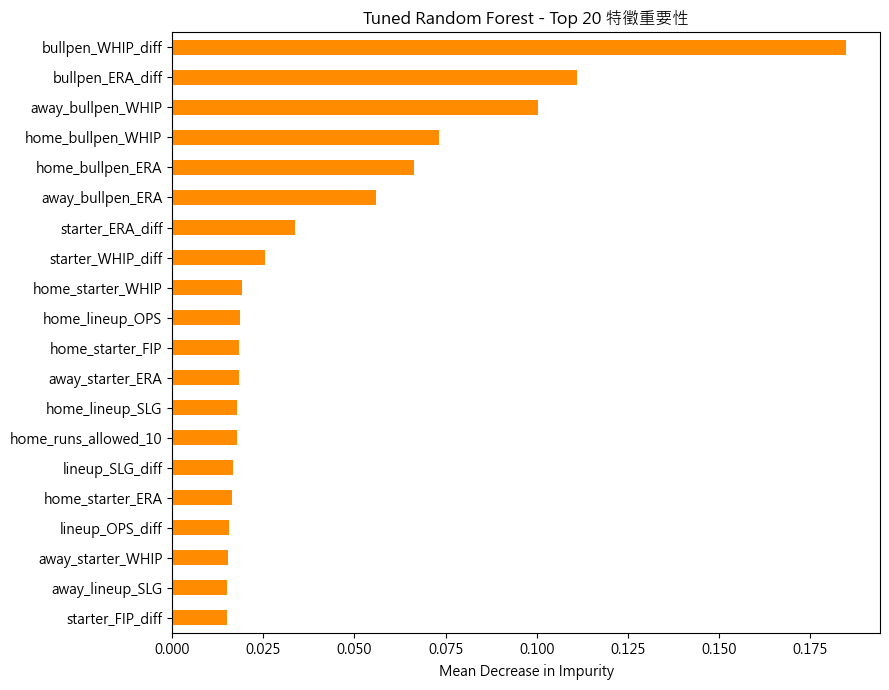

feature_importance_rf_tuned.png 已輸出


In [9]:
importances = (pd.Series(tuned_model.named_steps['rf'].feature_importances_, index=FEAT_COLS)
                 .sort_values(ascending=False))
top20 = importances.head(20)

fig, ax = plt.subplots(figsize=(9, 7))
top20[::-1].plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('Tuned Random Forest - Top 20 特徵重要性')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance_rf_tuned.png', dpi=150)
plt.show()
print('feature_importance_rf_tuned.png 已輸出')
